In [38]:
import epics
import time
import matplotlib.pyplot as plt
import numpy as np


kly1_amp = "IRFEL:MW:LLRF:KLY1:GET_CH8_AMP"
kly1_pha = "IRFEL:MW:LLRF:KLY1:GET_CH8_PHASE"

shb_amp = "IRFEL:MW:LLRF:SHB:GET_CH1_AMP"
shb_pha = "IRFEL:MW:LLRF:SHB:GET_CH1_PHASE"

Ebeam = "IRFEL:BD:ESA:H:E"

pvl = [shb_amp,shb_pha,kly1_amp,kly1_pha,Ebeam]

num = 60*5
vall = []
for j in range(num):
    vall.append(epics.caget_many(pvl))
    time.sleep(1)

val = np.array(vall)
np.savetxt("2024-04-30-jitter.txt",vall,fmt="%.6e")

In [43]:
# jitter

jitter1 = []
jitter2 = []
for j in range(5):
    data = val[:,j]

    tmp1 = np.std(data)/np.mean(data)*100
    tmp2 = np.std(data)
    
    jitter1.append(round(tmp1,2))
    jitter2.append(round(tmp2,2))

print("SHB amp, SHB phase(deg), KLY1 amp, KLY1 phase(deg), beam Energy (MeV)")
print("norm jitter (%) =",jitter1) 
print("rms jitter =",jitter2) 


SHB amp, SHB phase(deg), KLY1 amp, KLY1 phase(deg), beam Energy (MeV)
norm jitter (%) = [0.05, 0.01, 0.02, 0.41, 0.23]
rms jitter = [7.01, 0.01, 1.46, 0.04, 0.07]


array([6309.90722656, 6308.37939453])

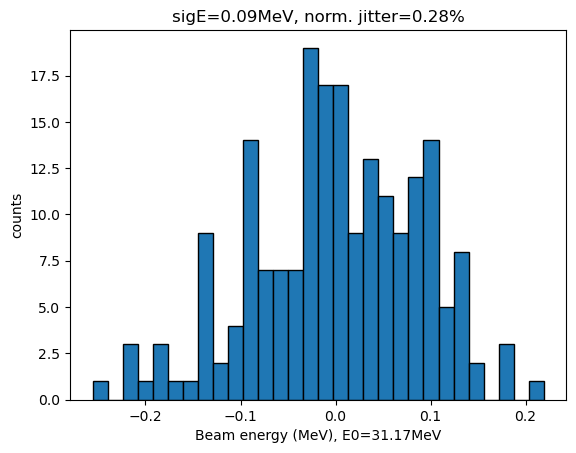

In [31]:
E0 =  val[:,4]

# rms jitter
sigE   = np.std(E0)
cenE0  = np.mean(E0)
jitter = np.std(E0)/np.mean(E0)*100

plt.hist(E0-cenE0,30,edgecolor="k")
plt.xlabel("Beam energy (MeV), E0="+str(round(cenE0,2))+"MeV")
plt.ylabel("counts")

title = "sigE="+str(round(sigE,2))+"MeV, norm. jitter="+str(round(jitter,2))+"%"
plt.title(title)

plt.savefig(str(cenE0)+'.png')
plt.show()

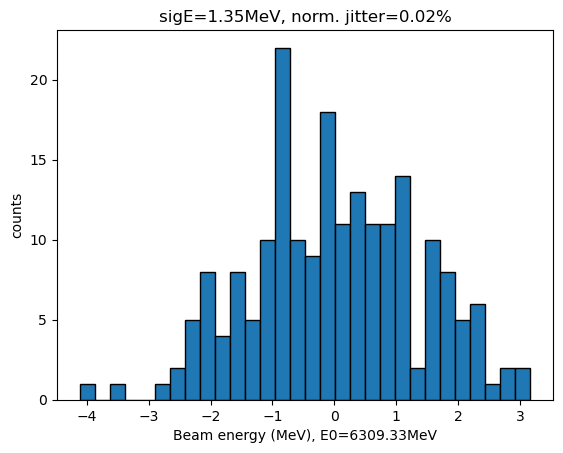

In [32]:
E0 =  val[:,0]

# rms jitter
sigE   = np.std(E0)
cenE0  = np.mean(E0)
jitter = np.std(E0)/np.mean(E0)*100

plt.hist(E0-cenE0,30,edgecolor="k")
plt.xlabel("Beam energy (MeV), E0="+str(round(cenE0,2))+"MeV")
plt.ylabel("counts")

title = "sigE="+str(round(sigE,2))+"MeV, norm. jitter="+str(round(jitter,2))+"%"
plt.title(title)

plt.savefig(str(cenE0)+'.png')
plt.show()